In [1]:
import torchvision
from torchvision import transforms
import torch
from torch.utils.data import DataLoader, random_split
from torch import nn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import copy
import seaborn as sns

torch.manual_seed(42)

Here we select the device to be used for training. We use a GPU if available.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Download the FashionMNIST Dataset using `torchvision`, transform the dataset to tensor and normalize it from [0,1]

In [ ]:
transform = transforms.ToTensor()  # transformer to tensor and normalizes to [0, 1]

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, 
                                                    download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, 
                                                   download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 191kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.3MB/s]


Reserve 10% of the training dataset for the validation dataset.

In [ ]:
# Reserve 10% of training set as validation (as per your assignment)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

We create a CustomCNN Model below.

In [5]:
class CustomCNN(nn.Module):
    def __init__(self, ):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1) # output dims (32, 28, 28)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output dims (32, 14, 14)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # output dims (64, 14, 14)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output dims (64, 7, 7)
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)
        
    def forward(self, X):
        X = torch.relu(self.conv1(X))
        X = self.maxpool1(X)
        X = torch.relu(self.conv2(X))
        X = torch.flatten(self.maxpool2(X), start_dim=1)
        X = torch.relu(self.fc1(X))
        return self.fc2(X)

In [7]:
torch.backends.cudnn.enabled = False

In [ ]:
class Runner:
    def __init__(self, model, optim, loss, train_loader, val_loader, test_loader, patience = 10):
        self._model = model
        self._optim = optim
        self._loss = loss
        self._train_loader = train_loader
        self._val_loader = val_loader
        self.test_loader = test_loader
        self._patience = patience

    def train(self):
        # statistics to save
        self.train_avg_losses = []
        self.train_accs = []

        self.val_avg_losses = []
        self.val_accs = []

        # variables for training
        curr_epoch = 0
        best_val_loss = float('inf')
        self.best_model = self._model
        patience_counter = 0
        while True:
            curr_epoch += 1
            print(f"---- Epoch {curr_epoch} ----")
            self._model.train()
            train_loss = 0
            train_total = 0
            train_correct = 0
            for images, labels in train_loader:
                # transfer data to the compute device
                images, labels = images.to(device), labels.to(device)
                images, labels = images.float(), labels.long()
                # perform predictions
                output = self._model(images)
                l = self._loss(output, labels)
                
                # store data
                predictions = torch.argmax(output, dim=1)
                train_loss += l.item()
                train_total += labels.size(0) # keep track of the total dataset since you don't know the size of the last batch
                train_correct += (predictions == labels).sum().item()
                
                # apply backpropagtion
                self._optim.zero_grad()
                l.backward()
                self._optim.step()
            
            self.train_avg_losses.append(train_loss/len(train_loader))
            self.train_accs.append((train_correct/train_total)*100)

            print(f"Avg training loss: {self.train_avg_losses[-1]:.4f}")
            print(f"Training accuracy: {self.train_accs[-1]:.4f}%")

            val_loss = 0
            val_total = 0
            val_correct = 0
            self._model.eval()
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                images, labels = images.float(), labels.long()

                output = self._model(images)

                l = self._loss(output, labels)

                predictions = torch.argmax(output, dim=1)
                val_loss += l.item()
                val_total += labels.size(0)
                val_correct += (predictions == labels).sum().item()
            
            self.val_avg_losses.append(val_loss/len(val_loader))
            self.val_accs.append((val_correct/val_total)*100)

            print(f"Avg validation loss: {self.val_avg_losses[-1]:.4f}")
            print(f"Validation accuracy: {self.val_accs[-1]:.4f}%")
            
            if self.val_avg_losses[-1] < best_val_loss:
                best_val_loss = self.val_avg_losses[-1]
                self._best_model = copy.deepcopy(self._model)
                patience_counter = 0
            else:
                patience_counter += 1
            
            print(f"Patience counter: {patience_counter}/{self._patience}")

            if patience_counter >= self._patience:
                print(f"Early stopping as patience counter has reached max value.")
                break

        self.final_epoch = curr_epoch
        self.selected_epoch = curr_epoch - self.patience

    def test(self):
        self.best_model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                images = images.float()
                output = self.best_model(images)
                predictions = torch.argmax(output, dim=1)
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        self.acc_score = accuracy_score(all_labels, all_preds)*100
        self.conf_matrix = confusion_matrix(all_labels, all_preds, )
        self.class_report = classification_report(all_labels, all_preds)
        print(f"Test Accuracy:{self.acc_score}%")
        print(f"Confusion Matrix:\n{self.conf_matrix}")
        print(f"Per-class metrics:\n{self.class_report}")

    def show_test_results(self, title, classes):
        sns.heatmap(self.conf_matrix, annot=True, fmt='d', 
                    xticklabels=classes,
                    yticklabels=classes)
        plt.xlabel('Model Predictions')
        plt.ylabel('True Labels')
        plt.title(title)
        plt.show()


In [22]:
model = CustomCNN().float().to(device)

# hyper params
lr = 0.001
weight_decay=0.01
optim = torch.optim.AdamW(model.parameters(), lr, weight_decay=weight_decay)
loss = nn.CrossEntropyLoss()
patience = 10

runner = Runner(model, optim, loss, train_loader, val_loader, patience)
runner.train()


---- Epoch 1 ----
Avg training loss: 0.4862
Training accuracy: 82.3204%
Avg validation loss: 0.3548
Validation accuracy: 87.5833%
Patience counter: 0/10
---- Epoch 2 ----
Avg training loss: 0.3134
Training accuracy: 88.5352%
Avg validation loss: 0.2937
Validation accuracy: 89.1833%
Patience counter: 0/10
---- Epoch 3 ----
Avg training loss: 0.2666
Training accuracy: 90.1593%
Avg validation loss: 0.2945
Validation accuracy: 89.2667%
Patience counter: 1/10
---- Epoch 4 ----
Avg training loss: 0.2379
Training accuracy: 91.3000%
Avg validation loss: 0.2579
Validation accuracy: 90.8333%
Patience counter: 0/10
---- Epoch 5 ----
Avg training loss: 0.2141
Training accuracy: 92.0926%
Avg validation loss: 0.2439
Validation accuracy: 90.8167%
Patience counter: 0/10
---- Epoch 6 ----
Avg training loss: 0.1934
Training accuracy: 92.8259%
Avg validation loss: 0.2363
Validation accuracy: 91.5167%
Patience counter: 0/10
---- Epoch 7 ----
Avg training loss: 0.1759
Training accuracy: 93.4833%
Avg valida

In [ ]:
selected_epoch = runner.final_epoch-patience
train_loss = runner.train_avg_losses[selected_epoch-1]
train_acc = runner.train_accs[selected_epoch-1]
best_val_loss = runner.val_avg_losses[selected_epoch-1]
val_acc = runner.val_accs[selected_epoch-1]

print(f"Best epoch: {selected_epoch}")
print(f"Train Loss: {train_loss}")
print(f"Training Accuracy: {train_acc}%")
print(f"Best Validation Loss: {best_val_loss}")
print(f"Validation Accuracy: {val_acc}%")


Best epoch: 9
Train Loss: 0.14465755834222122
Training Accuracy: 94.63333333333334%
Best Validation Loss: 0.2179648740653028
Validation Accuracy: 92.53333333333333%


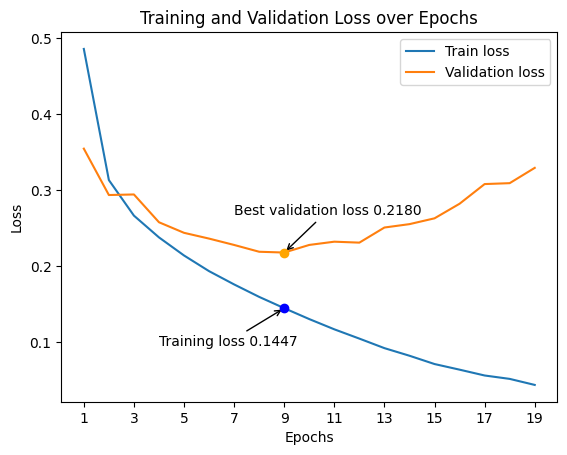

In [ ]:
epochs = [i for i in range(1, runner.final_epoch+1)]
xticks = []
for i in epochs:
    if (i+1)%2==0 or i == selected_epoch:
        xticks.append(i)
        
plt.plot(epochs, runner.train_avg_losses)
plt.plot(epochs, runner.val_avg_losses)

# annotate train_loss
plt.scatter(selected_epoch, train_loss, color='blue', zorder=5)
plt.annotate(
    f'Training loss {train_loss:.4f}',
    xy=(selected_epoch, train_loss),
    xytext=(selected_epoch-5, train_loss-0.05),
    arrowprops=dict(arrowstyle='->')
)

# annotate val_loss
plt.scatter(selected_epoch, best_val_loss, color='orange', zorder=5)
plt.annotate(
    f'Best validation loss {best_val_loss:.4f}',
    xy=(selected_epoch, best_val_loss),
    xytext=(selected_epoch-2, best_val_loss+0.05),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(xticks, xticks)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train loss", "Validation loss"])
plt.title("Training and Validation Loss over Epochs")
plt.show()

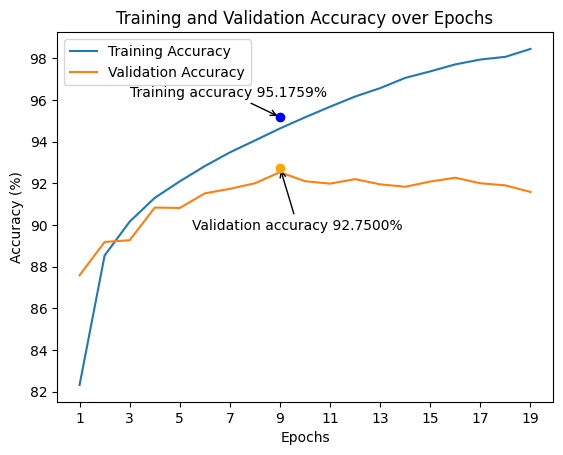

In [24]:
plt.plot(epochs, runner.train_accs)
plt.plot(epochs, runner.val_accs)

# annotate train_acc
plt.scatter(selected_epoch, train_acc, color='blue', zorder=5)
plt.annotate(
    f'Training accuracy {train_acc:.4f}%',
    xy=(selected_epoch, train_acc),
    xytext=(selected_epoch-6, train_acc+1),
    arrowprops=dict(arrowstyle='->')
)

# annotate val_loss
plt.scatter(selected_epoch, val_acc, color='orange', zorder=5)
plt.annotate(
    f'Validation accuracy {val_acc:.4f}%',
    xy=(selected_epoch, val_acc),
    xytext=(selected_epoch-3.5, val_acc-3),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(xticks, xticks)
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.title("Training and Validation Accuracy over Epochs")
plt.show()

In [ ]:
runner.test()

Test Accuracy:91.73%
Confusion Matrix:
[[916   0  20  17   1   1  36   0   9   0]
 [  3 984   0  10   2   0   0   0   1   0]
 [ 20   0 899   8  35   1  37   0   0   0]
 [ 15   3  10 943  15   0  12   0   2   0]
 [  2   1  62  26 865   0  41   0   3   0]
 [  0   0   0   0   0 984   0  14   0   2]
 [153   1  76  31  71   0 658   0  10   0]
 [  0   0   0   0   0   5   0 978   0  17]
 [  2   1   0   5   0   2   0   4 986   0]
 [  1   0   0   0   0   7   0  32   0 960]]
Per-class metrics:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1000
           1       0.99      0.98      0.99      1000
           2       0.84      0.90      0.87      1000
           3       0.91      0.94      0.92      1000
           4       0.87      0.86      0.87      1000
           5       0.98      0.98      0.98      1000
           6       0.84      0.66      0.74      1000
           7       0.95      0.98      0.96      1000
           8       0.98 

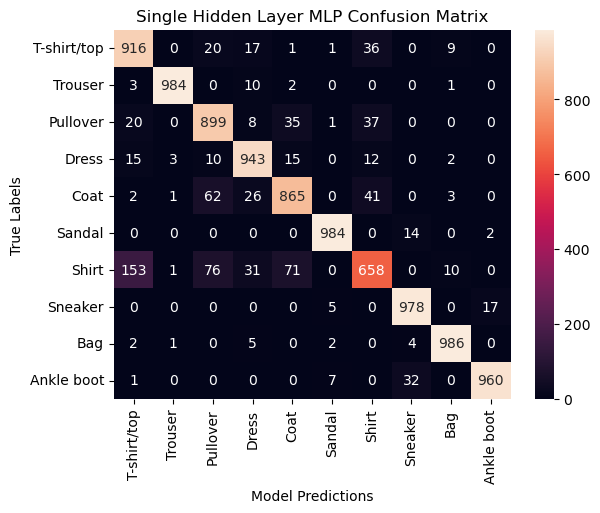

In [ ]:
runner.show_test_results(
    title='Model Predictions', 
    classes=train_dataset.classes
)

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # flip image horizontally
    transforms.RandomRotation(10),           # rotate ±10 degrees
    transforms.RandomCrop(28, padding=4),    # crop with padding
    transforms.ToTensor(),
])

train_dataset.transform = train_transform

In [ ]:
# Reserve 10% of training set as validation (as per your assignment)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model = CustomCNN().float().to(device)

# hyper params
lr = 0.001
weight_decay=0.01
optim = torch.optim.AdamW(model.parameters(), lr, weight_decay=weight_decay)
loss = nn.CrossEntropyLoss()
patience = 10

tr_loop = runner(model, optim, loss, train_loader, val_loader, patience)
runner.train()

---- Epoch 1 ----
Avg training loss: 0.4646
Training accuracy: 83.1481%
Avg validation loss: 0.3341
Validation accuracy: 88.1167%
Patience counter: 0/10
---- Epoch 2 ----
Avg training loss: 0.2981
Training accuracy: 89.1370%
Avg validation loss: 0.2865
Validation accuracy: 89.6167%
Patience counter: 0/10
---- Epoch 3 ----
Avg training loss: 0.2531
Training accuracy: 90.7130%
Avg validation loss: 0.2778
Validation accuracy: 89.9500%
Patience counter: 0/10
---- Epoch 4 ----
Avg training loss: 0.2217
Training accuracy: 91.8037%
Avg validation loss: 0.2539
Validation accuracy: 90.7167%
Patience counter: 0/10
---- Epoch 5 ----
Avg training loss: 0.1976
Training accuracy: 92.7389%
Avg validation loss: 0.2537
Validation accuracy: 90.6167%
Patience counter: 0/10
---- Epoch 6 ----
Avg training loss: 0.1810
Training accuracy: 93.2167%
Avg validation loss: 0.2190
Validation accuracy: 92.0500%
Patience counter: 0/10
---- Epoch 7 ----
Avg training loss: 0.1598
Training accuracy: 94.0241%
Avg valida

In [ ]:
runner.test()

In [ ]:
runner.show_test_results(
    title='Model Predictions with Augmented Training Data', 
    classes=train_dataset.classes
)